In [16]:
#imports 
from pathlib import Path

import torch
from torch import nn

from ray import tune
from ray.tune import Tuner, TuneConfig
from ray.tune.schedulers import ASHAScheduler

from sklearn.metrics import (
    accuracy_score,
    recall_score,
)

from mads_datasets.base import BaseDatastreamer
from mltrainer.preprocessors import BasePreprocessor

from src import datasets
from src.networks import ParallelCNN2D

In [3]:
# configuratie en bestanden inladen
import tomllib

datadir = Path("../data")
configfile = Path("config.toml")

with configfile.open("rb") as f:
    config = tomllib.load(f)

trainfile = datadir / (
    config["arrhythmia"] + "_train.parq"
)

testfile = datadir / (
    config["arrhythmia"] + "_test.parq"
)

trainfile, testfile

(PosixPath('../data/heart_big_train.parq'),
 PosixPath('../data/heart_big_test.parq'))

In [4]:
# Dataset maken
shape = (16, 12)

traindataset = datasets.HeartDataset2D(
    trainfile,
    target="target",
    shape=shape,
)

testdataset = datasets.HeartDataset2D(
    testfile,
    target="target",
    shape=shape,
)

len(traindataset), len(testdataset)

(87554, 21892)

In [5]:
# Class weight berekenen

class_counts = torch.bincount(
    traindataset.y
)

class_weights = (
    class_counts.sum()
    / (
        len(class_counts)
        * class_counts.float()
    )
)

classes = ["N", "S", "V", "F", "Q"]

for cls, count, weight in zip(
    classes,
    class_counts,
    class_weights,
):
    print(
        f"{cls}: "
        f"count={count}, "
        f"weight={weight:.3f}"
    )

N: count=72471, weight=0.242
S: count=2223, weight=7.877
V: count=5788, weight=3.025
F: count=641, weight=27.318
Q: count=6431, weight=2.723


In [6]:
# Testen of model nog werkt na parameters toevoegen

model = ParallelCNN2D(
    num_classes=5,
    filters=16,
    matrixshape=(16, 12),
    large_kernel=5,
    dropout=0.2,
)

teststreamer = BaseDatastreamer(
    testdataset,
    preprocessor=BasePreprocessor(),
    batchsize=32,
)

x, y = next(teststreamer.stream())

with torch.no_grad():
    output = model(x)

print(x.shape)
print(output.shape)

torch.Size([32, 1, 16, 12])
torch.Size([32, 5])


In [6]:
# Ray train functie

def train_tune_model(config):
    trainstreamer = BaseDatastreamer(
        traindataset,
        preprocessor=BasePreprocessor(),
        batchsize=config["batch_size"],
    )

    teststreamer = BaseDatastreamer(
        testdataset,
        preprocessor=BasePreprocessor(),
        batchsize=config["batch_size"],
    )

    model = ParallelCNN2D(
        num_classes=5,
        filters=config["filters"],
        matrixshape=(16, 12),
        large_kernel=config["large_kernel"],
        dropout=config["dropout"],
    )

    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    for epoch in range(config["epochs"]):
        model.train()

        train_data = trainstreamer.stream()

        for _ in range(
            len(trainstreamer) // 5
        ):
            X, y = next(train_data)

            optimizer.zero_grad()

            logits = model(X)

            loss = loss_fn(
                logits,
                y,
            )

            loss.backward()
            optimizer.step()

        model.eval()

        y_true = []
        y_pred = []

        test_data = teststreamer.stream()

        with torch.no_grad():
            for _ in range(
                len(teststreamer) // 5
            ):
                X, y = next(test_data)

                predictions = (
                    model(X)
                    .argmax(dim=1)
                )

                y_true.extend(
                    y.numpy()
                )

                y_pred.extend(
                    predictions.numpy()
                )

        recalls = recall_score(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3, 4],
            average=None,
            zero_division=0,
        )

        macro_recall = recalls.mean()

        abnormal_recall = recalls[
            [1, 2, 3, 4]
        ].mean()

        accuracy = accuracy_score(
            y_true,
            y_pred,
        )

        tune.report(
            {
                "epoch": epoch + 1,
                "loss": float(loss.item()),
                "accuracy": accuracy,
                "macro_recall": macro_recall,
                "abnormal_recall": abnormal_recall,
                "recall_N": recalls[0],
                "recall_S": recalls[1],
                "recall_V": recalls[2],
                "recall_F": recalls[3],
                "recall_Q": recalls[4],
            }
        )

In [7]:
# Zoekruimte

search_space = {
    "learning_rate": tune.loguniform(
        1e-4,
        1e-2,
    ),
    "filters": tune.choice(
        [8, 16, 32, 64]
    ),
    "batch_size": tune.choice(
        [16, 32, 64]
    ),
    "weight_decay": tune.loguniform(
        1e-6,
        1e-3,
    ),
    "dropout": tune.uniform(
        0.0,
        0.4,
    ),
    "large_kernel": tune.choice(
        [5, 7]
    ),
    "epochs": 10,
}

# filters: modelcapaciteit
# learning_rate: grootte van gewichtsupdates
# batch_size: stabiliteit en frequentie van updates
# weight_decay: regularisatie
# dropout: regularisatie
# large_kernel: schaal van de tweede route

In [8]:
# Schedular

scheduler = ASHAScheduler(
    time_attr="training_iteration",
    metric="macro_recall",
    mode="max",
    max_t=10,
    grace_period=3,
    reduction_factor=2,
)

In [9]:
# Tunen

trainable = tune.with_resources(
    train_tune_model,
    resources={
        "cpu": 1,
    },
)

In [10]:
tuner = Tuner(
    trainable,
    param_space=search_space,
    tune_config=TuneConfig(
        scheduler=scheduler,
        num_samples=20,
        max_concurrent_trials=1,
    ),
    run_config=tune.RunConfig(
        name="parallel_2d_hypertuning",
        storage_path=str(
            Path("ray_results").resolve()
        ),
    ),
)

In [11]:
results = tuner.fit()

(raylet) Warning: The actor ImplicitFunc is very large (81 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.


2026-07-16 14:20:48,709	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/azureuser/MADS-ML-EXAM-ML/notebooks/ray_results/parallel_2d_hypertuning' in 0.0194s.
2026-07-16 14:20:48,722	INFO tune.py:1041 -- Total run time: 1618.05 seconds (1617.52 seconds for the tuning loop).


In [12]:
# Beste configuratie

best_result = results.get_best_result(
    metric="macro_recall",
    mode="max",
)

print("Beste configuratie:")
print(best_result.config)

print("\nBeste macro-recall:")
print(
    best_result.metrics["macro_recall"]
)

print("\nRecall per klasse:")

for cls in classes:
    print(
        f"{cls}: "
        f"{best_result.metrics[f'recall_{cls}']:.3f}"
    )


Beste configuratie:
{'learning_rate': 0.0023652192398329417, 'filters': 32, 'batch_size': 16, 'weight_decay': 0.0001240120827027351, 'dropout': 0.13132723188719644, 'large_kernel': 7, 'epochs': 10}

Beste macro-recall:
0.8795380149254054

Recall per klasse:
N: 0.900
S: 0.811
V: 0.891
F: 0.826
Q: 0.969


In [13]:
# Alles in dataframe zetten

tuning_results = results.get_dataframe()

tuning_results.head()


,epoch,loss,accuracy,macro_recall,abnormal_recall,recall_N,recall_S,recall_V,recall_F,recall_Q,...,time_since_restore,iterations_since_restore,config/learning_rate,config/filters,config/batch_size,config/weight_decay,config/dropout,config/large_kernel,config/epochs,logdir
0,10,0.362981,0.804258,0.750827,0.735440,0.812377,0.516129,0.710801,0.813953,0.900875,...,62.235708,10,0.000106,8,16,0.000041,0.059856,7,10,c69d9_00000
1,10,0.827548,0.750460,0.846504,0.877857,0.721092,0.780488,0.847751,0.920000,0.963190,...,44.913165,10,0.006140,16,64,0.000085,0.160851,5,10,c69d9_00001
2,10,0.248689,0.747243,0.855997,0.890650,0.717385,0.805310,0.833333,0.958333,0.965625,...,189.205170,10,0.008425,64,32,0.000003,0.389509,7,10,c69d9_00002
3,10,0.502081,0.901786,0.879538,0.874300,0.900492,0.810811,0.891228,0.826087,0.969072,...,108.534571,10,0.002365,32,16,0.000124,0.131327,7,10,c69d9_00003
4,10,0.675952,0.855239,0.856946,0.859676,0.846026,0.720721,0.907473,0.848485,0.962025,...,207.685055,10,0.007120,64,32,0.000535,0.073928,5,10,c69d9_00004


In [14]:
# Pak relevante kolommen

tuning_summary = tuning_results[
    [
        "config/learning_rate",
        "config/filters",
        "config/batch_size",
        "config/weight_decay",
        "config/dropout",
        "config/large_kernel",
        "accuracy",
        "macro_recall",
        "abnormal_recall",
        "recall_N",
        "recall_S",
        "recall_V",
        "recall_F",
        "recall_Q",
    ]
].copy()

tuning_summary = tuning_summary.sort_values(
    "macro_recall",
    ascending=False,
)

tuning_summary.head(10).round(4)

,config/learning_rate,config/filters,config/batch_size,config/weight_decay,config/dropout,config/large_kernel,accuracy,macro_recall,abnormal_recall,recall_N,recall_S,recall_V,recall_F,recall_Q
3,0.0024,32,16,0.0001,0.1313,7,0.9018,0.8795,0.8743,0.9005,0.8108,0.8912,0.8261,0.9691
7,0.0051,64,64,0.0000,0.0432,5,0.8205,0.8747,0.8937,0.7988,0.7826,0.9139,0.9000,0.9784
10,0.0039,32,32,0.0000,0.3798,7,0.8433,0.8691,0.8786,0.8308,0.7500,0.8904,0.9211,0.9531
18,0.0021,16,16,0.0000,0.1079,7,0.8855,0.8646,0.8594,0.8852,0.7246,0.8908,0.8571,0.9649
4,0.0071,64,32,0.0005,0.0739,5,0.8552,0.8569,0.8597,0.8460,0.7207,0.9075,0.8485,0.9620
2,0.0084,64,32,0.0000,0.3895,7,0.7472,0.8560,0.8907,0.7174,0.8053,0.8333,0.9583,0.9656
1,0.0061,16,64,0.0001,0.1609,5,0.7505,0.8465,0.8779,0.7211,0.7805,0.8478,0.9200,0.9632
9,0.0020,8,16,0.0004,0.2198,5,0.8551,0.8283,0.8218,0.8545,0.5652,0.8650,0.9062,0.9506
15,0.0043,64,16,0.0000,0.2632,7,0.9219,0.8274,0.8006,0.9345,0.6930,0.8620,0.7097,0.9379
8,0.0019,32,32,0.0009,0.2968,5,0.8111,0.8166,0.8205,0.8010,0.5607,0.9066,0.8857,0.9288


In [15]:
# Opslaan

Path("results").mkdir(
    parents=True,
    exist_ok=True,
)

tuning_summary.to_csv(
    "results/ray_tuning_results.csv",
    index=False,
)

In [11]:
# BEste configuratie opnieuw trainen

import pandas as pd

tuning_results = pd.read_csv(
    "results/ray_tuning_results.csv"
)

best_config = tuning_results.loc[
    tuning_results["macro_recall"].idxmax()
]

best_config

config/learning_rate     0.002365
config/filters          32.000000
config/batch_size       16.000000
config/weight_decay      0.000124
config/dropout           0.131327
config/large_kernel      7.000000
accuracy                 0.901786
macro_recall             0.879538
abnormal_recall          0.874300
recall_N                 0.900492
recall_S                 0.810811
recall_V                 0.891228
recall_F                 0.826087
recall_Q                 0.969072
Name: 0, dtype: float64

2026-07-20 07:50:17.854 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/Parallelle 2D CNN hypertuned/run_1/20260720-075017



Parallelle 2D CNN hypertuned - run 1


100%|██████████| 1094/1094 [00:08<00:00, 128.40it/s]
2026-07-20 07:50:29.856 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.7813 test 0.5931 metric ['0.8345', '0.8345', '0.6048', '0.8345', '0.8252']
100%|██████████| 1094/1094 [00:08<00:00, 128.82it/s]
2026-07-20 07:50:41.825 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.5243 test 0.4996 metric ['0.8329', '0.8329', '0.5951', '0.8329', '0.8572']
100%|██████████| 1094/1094 [00:08<00:00, 132.18it/s]
2026-07-20 07:50:53.493 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.4682 test 0.4354 metric ['0.9151', '0.9151', '0.7408', '0.9151', '0.8757']
100%|██████████| 1094/1094 [00:08<00:00, 132.32it/s]
2026-07-20 07:51:05.152 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.4317 test 0.4238 metric ['0.8926', '0.8926', '0.6873', '0.8926', '0.8767']
100%|██████████| 1094/1094 [00:08<00:00, 129.97it/s]
2026-07-20 07:51:16.989 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.4090 test 0.445

Accuracy: 0.821
Recall: [0.798 0.823 0.934 0.888 0.979]
Trainingstijd: 179.5 seconden

Parallelle 2D CNN hypertuned - run 2


100%|██████████| 1094/1094 [00:09<00:00, 120.59it/s]
2026-07-20 07:53:33.009 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.7786 test 0.6851 metric ['0.8773', '0.8773', '0.6583', '0.8773', '0.7913']
100%|██████████| 1094/1094 [00:08<00:00, 128.82it/s]
2026-07-20 07:53:44.869 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.5642 test 0.4868 metric ['0.8132', '0.8132', '0.5776', '0.8132', '0.8423']
100%|██████████| 1094/1094 [00:08<00:00, 123.32it/s]
2026-07-20 07:53:57.036 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.4939 test 0.4258 metric ['0.8723', '0.8723', '0.6587', '0.8723', '0.8696']
100%|██████████| 1094/1094 [00:08<00:00, 129.56it/s]
2026-07-20 07:54:08.837 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.4427 test 0.4198 metric ['0.9238', '0.9238', '0.7546', '0.9238', '0.8744']
100%|██████████| 1094/1094 [00:08<00:00, 133.89it/s]
2026-07-20 07:54:20.375 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.3993 test 0.400

...

Accuracy: 0.944
Recall: [0.953 0.672 0.911 0.852 0.975]
Trainingstijd: 177.4 seconden

Parallelle 2D CNN hypertuned - run 4


100%|██████████| 1094/1094 [00:08<00:00, 127.58it/s]
2026-07-20 07:59:35.980 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.7520 test 0.5882 metric ['0.8544', '0.8544', '0.6191', '0.8544', '0.8142']
100%|██████████| 1094/1094 [00:08<00:00, 126.91it/s]
2026-07-20 07:59:47.983 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.5248 test 0.4131 metric ['0.8974', '0.8974', '0.6996', '0.8974', '0.8725']
100%|██████████| 1094/1094 [00:08<00:00, 129.97it/s]
2026-07-20 07:59:59.774 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.4952 test 0.5140 metric ['0.8796', '0.8796', '0.6605', '0.8796', '0.8460']
100%|██████████| 1094/1094 [00:08<00:00, 128.45it/s]
2026-07-20 08:00:11.697 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.4404 test 0.4292 metric ['0.8915', '0.8915', '0.6958', '0.8915', '0.8701']
100%|██████████| 1094/1094 [00:08<00:00, 133.07it/s]
2026-07-20 08:00:23.368 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.4290 test 0.414

Accuracy: 0.859
Recall: [0.845 0.85  0.921 0.816 0.969]
Trainingstijd: 176.3 seconden

Parallelle 2D CNN hypertuned - run 5


100%|██████████| 1094/1094 [00:08<00:00, 130.87it/s]
2026-07-20 08:02:35.179 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.7317 test 0.5584 metric ['0.8741', '0.8741', '0.6483', '0.8741', '0.8338']
100%|██████████| 1094/1094 [00:08<00:00, 132.95it/s]
2026-07-20 08:02:46.748 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.5852 test 0.5417 metric ['0.9137', '0.9137', '0.6994', '0.9137', '0.8323']
100%|██████████| 1094/1094 [00:08<00:00, 134.28it/s]
2026-07-20 08:02:58.305 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.4295 test 0.5261 metric ['0.8546', '0.8546', '0.6387', '0.8546', '0.8551']
100%|██████████| 1094/1094 [00:08<00:00, 130.80it/s]
2026-07-20 08:03:10.015 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.4728 test 0.4245 metric ['0.8929', '0.8929', '0.6878', '0.8929', '0.8740']
100%|██████████| 1094/1094 [00:08<00:00, 135.69it/s]
2026-07-20 08:03:21.408 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.3896 test 0.367

Accuracy: 0.887
Recall: [0.877 0.786 0.959 0.823 0.975]
Trainingstijd: 173.3 seconden


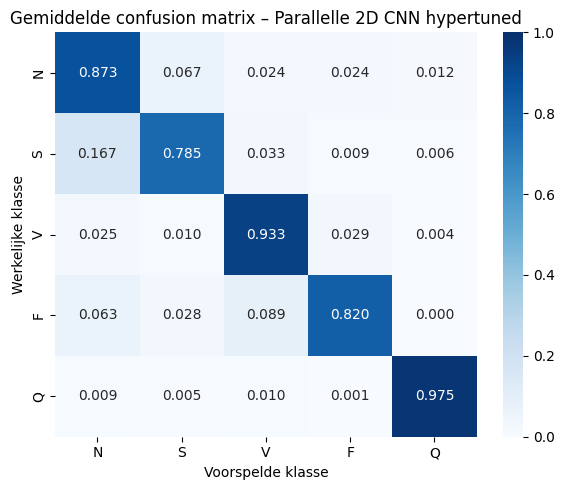

In [17]:
from src.helpers import run_experiment

best_model_results = run_experiment(
    model_function=lambda: ParallelCNN2D(
        num_classes=5,
        filters=int(best_config["config/filters"]),
        matrixshape=(16, 12),
        large_kernel=int(best_config["config/large_kernel"]),
        dropout=float(best_config["config/dropout"]),
    ),
    experiment_name="Parallelle 2D CNN hypertuned",
    trainstreamer=BaseDatastreamer(
        traindataset,
        preprocessor=BasePreprocessor(),
        batchsize=int(best_config["config/batch_size"]),
    ),
    teststreamer=BaseDatastreamer(
        testdataset,
        preprocessor=BasePreprocessor(),
        batchsize=int(best_config["config/batch_size"]),
    ),
    loss_fn=nn.CrossEntropyLoss(
        weight=class_weights,
    ),
    class_weights=True,
    parallel=True,
    runs=5,
    epochs=15,
    learning_rate=float(best_config["config/learning_rate"]),
    weight_decay=float(best_config["config/weight_decay"]),
    filename="results/results.csv",
)

In [13]:
tuning_results[
    [
        "macro_recall",
        "config/learning_rate",
        "config/batch_size",
        "config/filters",
        "config/dropout",
        "config/weight_decay",
        "config/large_kernel",
    ]
].sort_values(
    "macro_recall",
    ascending=False,
).head(10)

,macro_recall,config/learning_rate,config/batch_size,config/filters,config/dropout,config/weight_decay,config/large_kernel
0,0.879538,0.002365,16,32,0.131327,0.000124,7
1,0.874749,0.005095,64,64,0.043172,0.000012,5
2,0.869061,0.003882,32,32,0.379825,0.000006,7
3,0.864551,0.002121,16,16,0.107867,0.000020,7
4,0.856946,0.007120,32,64,0.073928,0.000535,5
5,0.855997,0.008425,32,64,0.389509,0.000003,7
6,0.846504,0.006140,64,16,0.160851,0.000085,5
7,0.828318,0.001981,16,8,0.219842,0.000412,5
8,0.827404,0.004297,16,64,0.263202,0.000002,7
9,0.816584,0.001851,32,32,0.296850,0.000867,5
